# Phase 3: Preprocessing

Tahapan ini bertujuan untuk membersihkan dan menyiapkan data sekuens agar siap dimasukkan ke dalam model *Deep Learning*.

**Langkah-langkah:**
1. Membuang sekuens yang mengandung asam amino non-standar (seperti X, B, Z, J, U, O).
2. Menganalisis distribusi panjang sekuens dan membuang outlier ekstrim (panjang > 1000) untuk menyesuaikan kapasitas VRAM (4GB).
3. *Label Encoding*.
4. Membagi dataset menjadi *Training Set* (70%), *Validation Set* (15%), dan *Testing Set* (15%) dengan metode *Stratified Split*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

os.makedirs('data/processed', exist_ok=True)

In [2]:
# 1. Memuat Data Raw
df = pd.read_csv('data/raw/protein_sequences.csv')
print(f"Total data awal: {len(df)}")
df.head()

Total data awal: 28467


,Entry,Entry_Name,Protein_Name,Length,Sequence,Family
0,P33981,TTK_HUMAN,Dual specificity protein kinase TTK (EC 2.7.12...,857,MESEDLSGRELTIDSIMNKVRDIKNKFKNEDLTDELSLNKISADTT...,Kinase
1,P49761,CLK3_HUMAN,Dual specificity protein kinase CLK3 (EC 2.7.1...,490,MHHCKRYRSPEPDPYLSYRWKRRRSYSREHEGRLRYPSRREPPPRR...,Kinase
2,Q6XUX3,DUSTY_HUMAN,Dual serine/threonine and tyrosine protein kin...,929,MEGDGVPWGSEPVSGPGPGGGGMIRELCRGFGRYRRYLGRLRQNLR...,Kinase
3,Q92630,DYRK2_HUMAN,Dual specificity tyrosine-phosphorylation-regu...,601,MLTRKPSAAAPAAYPTGRGGDSAVRQLQASPGLGAGATRSGVGTGP...,Kinase
4,P46734,MP2K3_HUMAN,Dual specificity mitogen-activated protein kin...,347,MESPASSQPASMPQSKGKSKRKKDLRISCMSKPPAPNPTPPRNLDS...,Kinase


In [3]:
# 2. Pembersihan Asam Amino Non-Standar
# Hanya mempertahankan 20 asam amino standar untuk kemudahan modeling di CNN/LSTM
standard_aa = set('ACDEFGHIKLMNPQRSTVWY')

def is_standard(seq):
    return set(seq).issubset(standard_aa)

df['is_valid'] = df['Sequence'].apply(is_standard)
df_clean = df[df['is_valid']].copy()
df_clean = df_clean.drop(columns=['is_valid'])

print(f"Total data setelah pembersihan: {len(df_clean)} (Dihapus: {len(df) - len(df_clean)})")

Total data setelah pembersihan: 28256 (Dihapus: 211)


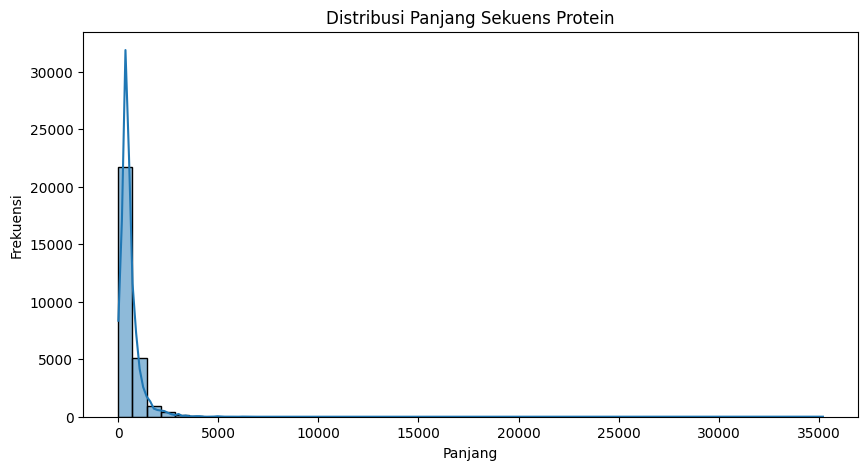

count    28256.000000
mean       559.820428
std        582.766043
min          4.000000
25%        303.000000
50%        436.000000
75%        676.000000
max      35213.000000
Name: Length, dtype: float64

Total data setelah memfilter panjang <= 1000: 25092 (Dihapus: 3164)


In [4]:
# 3. Analisis dan Pemfilteran Panjang Sekuens
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Length'], bins=50, kde=True)
plt.title('Distribusi Panjang Sekuens Protein')
plt.xlabel('Panjang')
plt.ylabel('Frekuensi')
plt.show()

print(df_clean['Length'].describe())

# Batas VRAM 4GB: Kita filter sekuens yang > 1000 agar batch training bisa cukup lega.
MAX_SEQ_LEN = 1000
df_filtered = df_clean[df_clean['Length'] <= MAX_SEQ_LEN].copy()

print(f"\nTotal data setelah memfilter panjang <= {MAX_SEQ_LEN}: {len(df_filtered)} (Dihapus: {len(df_clean) - len(df_filtered)})")

In [5]:
# 4. Encoding Label Kategori
le = LabelEncoder()
df_filtered['Label'] = le.fit_transform(df_filtered['Family'])

# Menyimpan mapping label
label_mapping = {int(k): str(v) for k, v in zip(le.transform(le.classes_), le.classes_)}
with open('data/processed/label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=4)

print("Mapping Label Tersimpan:")
print(json.dumps(label_mapping, indent=4))

Mapping Label Tersimpan:
{
    "0": "GPCR",
    "1": "Hydrolase",
    "2": "Ion Channel",
    "3": "Kinase",
    "4": "Oxidoreductase",
    "5": "Transcription Factor"
}



Jumlah data latih (Train): 17564
Jumlah data validasi (Val): 3764
Jumlah data uji (Test): 3764


C:\Users\Rey\AppData\Local\Temp\ipykernel_72088\4191832595.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, y='Family', palette='viridis')


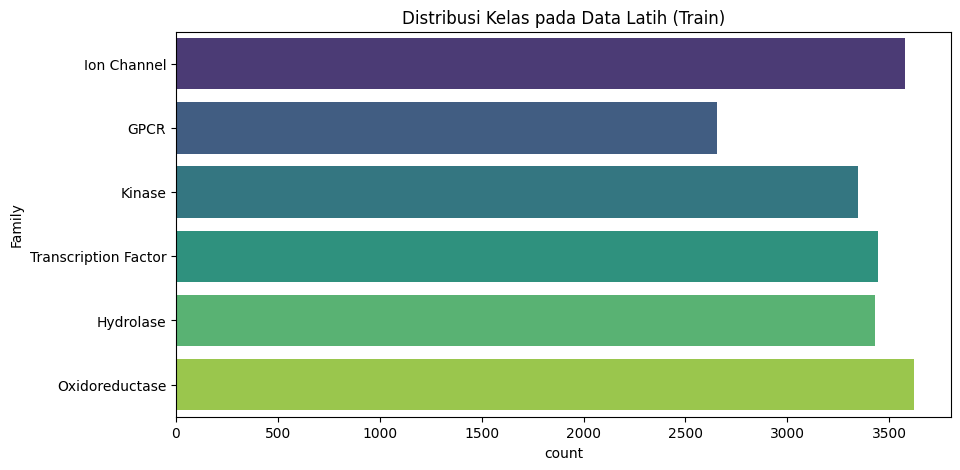

In [6]:
# 5. Train-Val-Test Split (Stratified 70:15:15)
X = df_filtered[['Entry', 'Sequence', 'Length']]
y = df_filtered[['Label', 'Family']]

# Split 70:30 dulu
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y['Label'], random_state=42
)

# Split 30 jadi 15:15
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp['Label'], random_state=42
)

train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print(f"\nJumlah data latih (Train): {len(train_df)}")
print(f"Jumlah data validasi (Val): {len(val_df)}")
print(f"Jumlah data uji (Test): {len(test_df)}")

plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, y='Family', palette='viridis')
plt.title('Distribusi Kelas pada Data Latih (Train)')
plt.show()

In [7]:
# 6. Menyimpan Hasil Akhir
train_df.to_csv('data/processed/train.csv', index=False)
val_df.to_csv('data/processed/val.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)
print("Data latih, validasi, dan uji berhasil disimpan ke 'data/processed/'")

Data latih, validasi, dan uji berhasil disimpan ke 'data/processed/'
